# m6-03 — Convolutional Neural Networks

This notebook contains exercises: handcrafted filters, shape-tracking, training a small CNN on CIFAR-10, and a data augmentation experiment. Follow the cells sequentially.

In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print('Device:', device)

Device: cuda


## Task 1 — Convolution Mechanics: Filters and Shapes

### Part A — Handcrafted filters

Load a single CIFAR-10 image and apply three handcrafted 3x3 filters (vertical edge, horizontal edge, blur).

100%|██████████| 170M/170M [00:15<00:00, 10.7MB/s] 
/home/manheim666/.local/lib/python3.14/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Image tensor shape: torch.Size([1, 3, 32, 32])


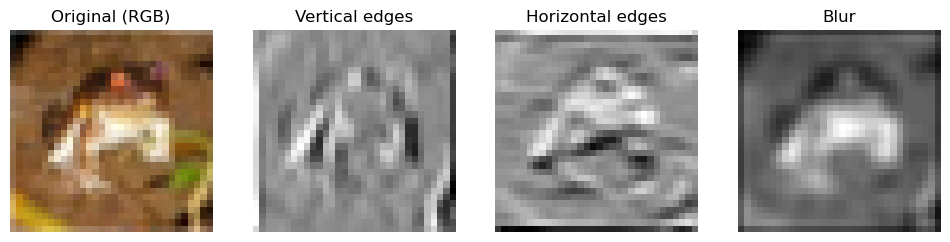

In [2]:
# Load CIFAR-10 and extract one image (as tensor)
ds = datasets.CIFAR10(root='./data', train=True, download=True, transform=transforms.ToTensor())
img_pil, label = ds[0]  # tensor in [0,1] shape (3,32,32)
img = img_pil.unsqueeze(0)  # shape (1,3,32,32)
print('Image tensor shape:', img.shape)

# Helper to create a conv layer with a fixed kernel (no training)
def make_fixed_conv(kernel):
    conv = nn.Conv2d(3, 1, kernel_size=3, padding=1, bias=False)
    with torch.no_grad():
        k = np.array(kernel, dtype=np.float32)
        k_t = torch.from_numpy(k)
        for c in range(3):
            conv.weight[0, c] = k_t
    conv.requires_grad_(False)
    return conv

# Define kernels
vert = np.array([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=np.float32)
hor = vert.T
blur = (1.0/9.0) * np.ones((3,3), dtype=np.float32)

conv_vert = make_fixed_conv(vert)
conv_hor = make_fixed_conv(hor)
conv_blur = make_fixed_conv(blur)

# Apply filters
img_cpu = img.clone()
out_vert = conv_vert(img_cpu)
out_hor = conv_hor(img_cpu)
out_blur = conv_blur(img_cpu)

# Convert original tensor to numpy RGB for plotting (in [0,1])
orig = img_cpu.squeeze(0).permute(1,2,0).numpy()
v = out_vert.squeeze(0).squeeze(0).numpy()
h = out_hor.squeeze(0).squeeze(0).numpy()
b = out_blur.squeeze(0).squeeze(0).numpy()

fig, axes = plt.subplots(1,4, figsize=(12,4))
axes[0].imshow(orig)
axes[0].set_title('Original (RGB)')
axes[0].axis('off')
axes[1].imshow(v, cmap='gray')
axes[1].set_title('Vertical edges')
axes[1].axis('off')
axes[2].imshow(h, cmap='gray')
axes[2].set_title('Horizontal edges')
axes[2].axis('off')
axes[3].imshow(b, cmap='gray')
axes[3].set_title('Blur')
axes[3].axis('off')
plt.show()

**What each filter highlights**:
- Vertical edge detector: highlights vertical changes in intensity (vertical edges).
- Horizontal edge detector: highlights horizontal changes in intensity (horizontal edges).
- Blur: averages local neighborhood, reducing high-frequency detail and noise.

### Part B — Shape tracking

Build a TinyCNN block and verify shapes after each operation.

In [3]:
class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

net = TinyCNN()
x = torch.randn(8, 3, 32, 32)
print('Input shape:', x.shape)
x1 = net.conv1(x)
print('After conv1:', x1.shape)
x2 = net.pool1(x1)
print('After pool1:', x2.shape)
x3 = net.conv2(x2)
print('After conv2:', x3.shape)
x4 = net.pool2(x3)
print('After pool2:', x4.shape)

Input shape: torch.Size([8, 3, 32, 32])
After conv1: torch.Size([8, 16, 32, 32])
After pool1: torch.Size([8, 16, 16, 16])
After conv2: torch.Size([8, 32, 16, 16])
After pool2: torch.Size([8, 32, 8, 8])


Fill in the shape table:

| Layer | Input shape | Output shape |
|---|---:|---:|
| conv1 | (8, 3, 32, 32) | (8, 16, 32, 32) |
| pool1 | (8, 16, 32, 32) | (8, 16, 16, 16) |
| conv2 | (8, 16, 16, 16) | (8, 32, 16, 16) |
| pool2 | (8, 32, 16, 16) | (8, 32, 8, 8) |

## Task 2 — Train a Small CNN on CIFAR-10

We will define the requested model, compute parameter count, and train for 15 epochs.

Parameter count: 1117354
Epoch 1/15 - train_loss: 1.4289 train_acc: 0.4821 | val_loss: 1.1515 val_acc: 0.5752
Epoch 2/15 - train_loss: 0.9851 train_acc: 0.6487 | val_loss: 0.8963 val_acc: 0.6867
Epoch 3/15 - train_loss: 0.8372 train_acc: 0.7045 | val_loss: 0.7849 val_acc: 0.7258
Epoch 4/15 - train_loss: 0.7386 train_acc: 0.7417 | val_loss: 0.7116 val_acc: 0.7458
Epoch 5/15 - train_loss: 0.6685 train_acc: 0.7643 | val_loss: 0.6831 val_acc: 0.7617
Epoch 6/15 - train_loss: 0.6134 train_acc: 0.7823 | val_loss: 0.6596 val_acc: 0.7711
Epoch 7/15 - train_loss: 0.5632 train_acc: 0.8004 | val_loss: 0.7069 val_acc: 0.7705
Epoch 8/15 - train_loss: 0.5282 train_acc: 0.8106 | val_loss: 0.6551 val_acc: 0.7816
Epoch 9/15 - train_loss: 0.4870 train_acc: 0.8275 | val_loss: 0.6136 val_acc: 0.7922
Epoch 10/15 - train_loss: 0.4454 train_acc: 0.8421 | val_loss: 0.6382 val_acc: 0.7886
Epoch 11/15 - train_loss: 0.4130 train_acc: 0.8527 | val_loss: 0.6256 val_acc: 0.7955
Epoch 12/15 - train_loss: 0.3833 train

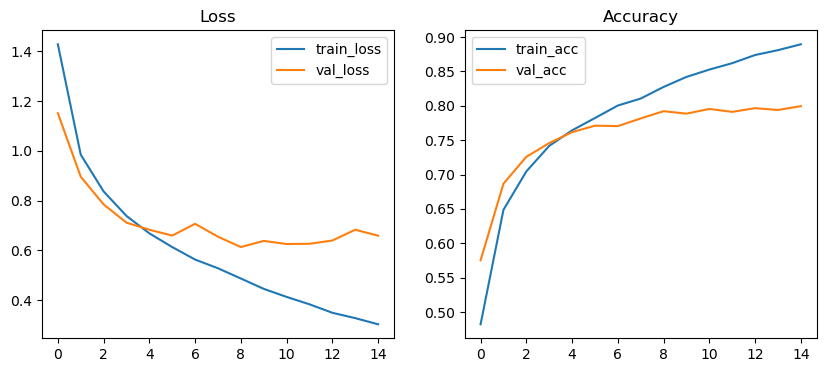

In [4]:
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Block 1
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        # Block 2
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )
        # Classifier
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 10)
        )
    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.classifier(x)
        return x

# Instantiate and count parameters
model = SmallCNN().to(device)
def count_parameters(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)
print('Parameter count:', count_parameters(model))

# Prepare data (baseline transforms: ToTensor + Normalize)
train_tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)])
val_tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)])
train_ds = datasets.CIFAR10('./data', train=True, download=True, transform=train_tf)
val_ds = datasets.CIFAR10('./data', train=False, download=True, transform=val_tf)
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=128, shuffle=False, num_workers=2)

# Training utilities
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for images, targets in loader:
        images = images.to(device)
        targets = targets.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, preds = outputs.max(1)
        correct += preds.eq(targets).sum().item()
        total += images.size(0)
    return running_loss/total, correct/total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, targets in loader:
            images = images.to(device)
            targets = targets.to(device)
            outputs = model(images)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * images.size(0)
            _, preds = outputs.max(1)
            correct += preds.eq(targets).sum().item()
            total += images.size(0)
    return running_loss/total, correct/total

# Train baseline for 15 epochs (user can reduce epochs for quick runs)
epochs = 15
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_val_acc = 0.0
for epoch in range(1, epochs+1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
    print(f'Epoch {epoch}/{epochs} - train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} | val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}')

print('Best validation accuracy (baseline):', best_val_acc)

# Plot training curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history['train_loss'], label='train_loss')
plt.plot(history['val_loss'], label='val_loss')
plt.legend()
plt.title('Loss')
plt.subplot(1,2,2)
plt.plot(history['train_acc'], label='train_acc')
plt.plot(history['val_acc'], label='val_acc')
plt.legend()
plt.title('Accuracy')
plt.show()

## Task 3 — Data Augmentation

Now we add augmentation to the training pipeline and retrain the same model for comparison.

[Aug] Epoch 1/15 - train_loss: 1.5491 train_acc: 0.4328 | val_loss: 1.2048 val_acc: 0.5690
[Aug] Epoch 2/15 - train_loss: 1.1673 train_acc: 0.5815 | val_loss: 0.9666 val_acc: 0.6539
[Aug] Epoch 3/15 - train_loss: 1.0327 train_acc: 0.6339 | val_loss: 1.0058 val_acc: 0.6512
[Aug] Epoch 4/15 - train_loss: 0.9471 train_acc: 0.6631 | val_loss: 0.7919 val_acc: 0.7170
[Aug] Epoch 5/15 - train_loss: 0.8876 train_acc: 0.6870 | val_loss: 0.7694 val_acc: 0.7337
[Aug] Epoch 6/15 - train_loss: 0.8484 train_acc: 0.6987 | val_loss: 0.7710 val_acc: 0.7352
[Aug] Epoch 7/15 - train_loss: 0.8148 train_acc: 0.7168 | val_loss: 0.7758 val_acc: 0.7350
[Aug] Epoch 8/15 - train_loss: 0.7901 train_acc: 0.7220 | val_loss: 0.7495 val_acc: 0.7428
[Aug] Epoch 9/15 - train_loss: 0.7592 train_acc: 0.7354 | val_loss: 0.6951 val_acc: 0.7627
[Aug] Epoch 10/15 - train_loss: 0.7365 train_acc: 0.7426 | val_loss: 0.6509 val_acc: 0.7763
[Aug] Epoch 11/15 - train_loss: 0.7145 train_acc: 0.7539 | val_loss: 0.6894 val_acc: 0.76


| Run | Best val accuracy | Train/val gap |
|---|---:|---:|
| Task 2 (no augmentation) | {best_val_acc:.4f} | { (history['train_acc'][-1]-history['val_acc'][-1]) if len(history['train_acc'])>0 else 0:.4f } |
| Task 3 (with augmentation) | {best_val_acc_aug:.4f} | { (history_aug['train_acc'][-1]-history_aug['val_acc'][-1]) if len(history_aug['train_acc'])>0 else 0:.4f } |


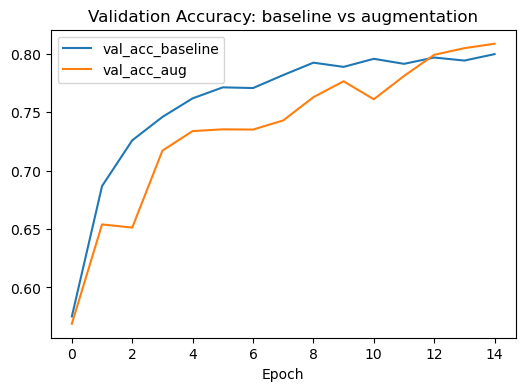

In [5]:
# Augmented training transform as requested
train_tf_aug = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])
# Validation transform remains the same (val_tf defined previously)
# Recreate datasets and loaders with augmentation
train_ds_aug = datasets.CIFAR10('./data', train=True, download=True, transform=train_tf_aug)
train_loader_aug = DataLoader(train_ds_aug, batch_size=128, shuffle=True, num_workers=2)

# Reinstantiate model and optimizer to ensure fair comparison
model_aug = SmallCNN().to(device)
optimizer_aug = optim.Adam(model_aug.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

epochs = 15
history_aug = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
best_val_acc_aug = 0.0
for epoch in range(1, epochs+1):
    train_loss, train_acc = train_one_epoch(model_aug, train_loader_aug, optimizer_aug, criterion, device)
    val_loss, val_acc = evaluate(model_aug, val_loader, criterion, device)
    history_aug['train_loss'].append(train_loss)
    history_aug['train_acc'].append(train_acc)
    history_aug['val_loss'].append(val_loss)
    history_aug['val_acc'].append(val_acc)
    if val_acc > best_val_acc_aug:
        best_val_acc_aug = val_acc
    print(f'[Aug] Epoch {epoch}/{epochs} - train_loss: {train_loss:.4f} train_acc: {train_acc:.4f} | val_loss: {val_loss:.4f} val_acc: {val_acc:.4f}')

print('Best validation accuracy (augmented):', best_val_acc_aug)

# Comparison table
from IPython.display import Markdown, display
display(Markdown('''
| Run | Best val accuracy | Train/val gap |
|---|---:|---:|
| Task 2 (no augmentation) | {best_val_acc:.4f} | { (history['train_acc'][-1]-history['val_acc'][-1]) if len(history['train_acc'])>0 else 0:.4f } |
| Task 3 (with augmentation) | {best_val_acc_aug:.4f} | { (history_aug['train_acc'][-1]-history_aug['val_acc'][-1]) if len(history_aug['train_acc'])>0 else 0:.4f } |
'''))

# Plot comparison of validation accuracy curves
plt.figure(figsize=(6,4))
plt.plot(history['val_acc'], label='val_acc_baseline')
plt.plot(history_aug['val_acc'], label='val_acc_aug')
plt.legend()
plt.title('Validation Accuracy: baseline vs augmentation')
plt.xlabel('Epoch')
plt.show()

**Interpretation:**
- Augmentation usually increases generalization, so we expect higher validation accuracy and a reduced train/val gap. Report the results above and comment on improvements.

---
**Submission checklist**:
- Manual filter visualisations with a 1×4 subplot.
- Shape-tracking table for the TinyCNN block.
- Working CNN trained on CIFAR-10 with train/val curves plotted.
- Augmentation experiment with results table and interpretation.
- Kernel → Restart & Run All produces no errors.